In [1]:
import pandas as pd

df=pd.read_csv('machine_temperature_system_failure.csv')
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')
df.index.diff()

#df.info  df.describe() df.isnull.().sum()

TimedeltaIndex([              NaT, '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00', '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00', '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00',
                ...
                '0 days 00:05:00', '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00', '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00', '0 days 00:05:00', '0 days 00:05:00',
                '0 days 00:05:00'],
               dtype='timedelta64[us]', name='timestamp', length=22695, freq=None)

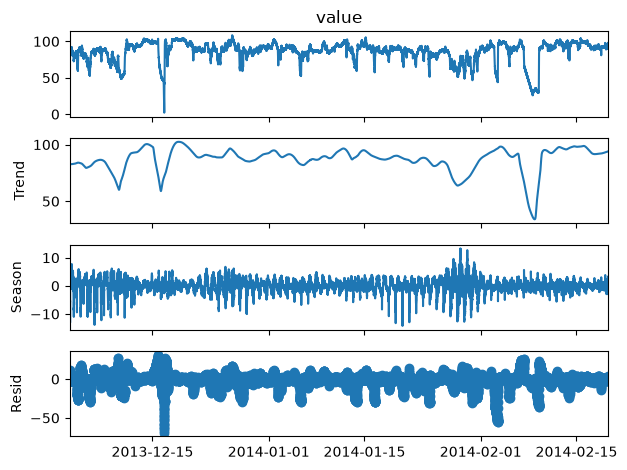

In [2]:
from statsmodels.tsa.seasonal import STL

stl=STL(df['value'],period=288,robust=True)  #STLは重い　ロバストは地獄
result=stl.fit()
result.plot();

#波形が似通っている＝分解できていない。STLは不適
#機械の停止による温度変化など構造変化に対応できない

In [3]:
df=df.sort_index()
df['2013-12-16 16:00:00':'2013-12-17'].head(40)

#緩やかに下がって上りは急、機械停止からの立ち上げ？

,value
timestamp,
2013-12-16 16:00:00,30.699649
2013-12-16 16:05:00,30.504461
2013-12-16 16:10:00,27.212228
2013-12-16 16:15:00,25.680672
2013-12-16 16:20:00,23.829044
2013-12-16 16:25:00,22.983839
2013-12-16 16:30:00,21.737032
2013-12-16 16:35:00,19.277179
2013-12-16 16:40:00,18.591971


C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_13840\1693025574.py:21: UserWarning: Glyph 20998 (\N{CJ

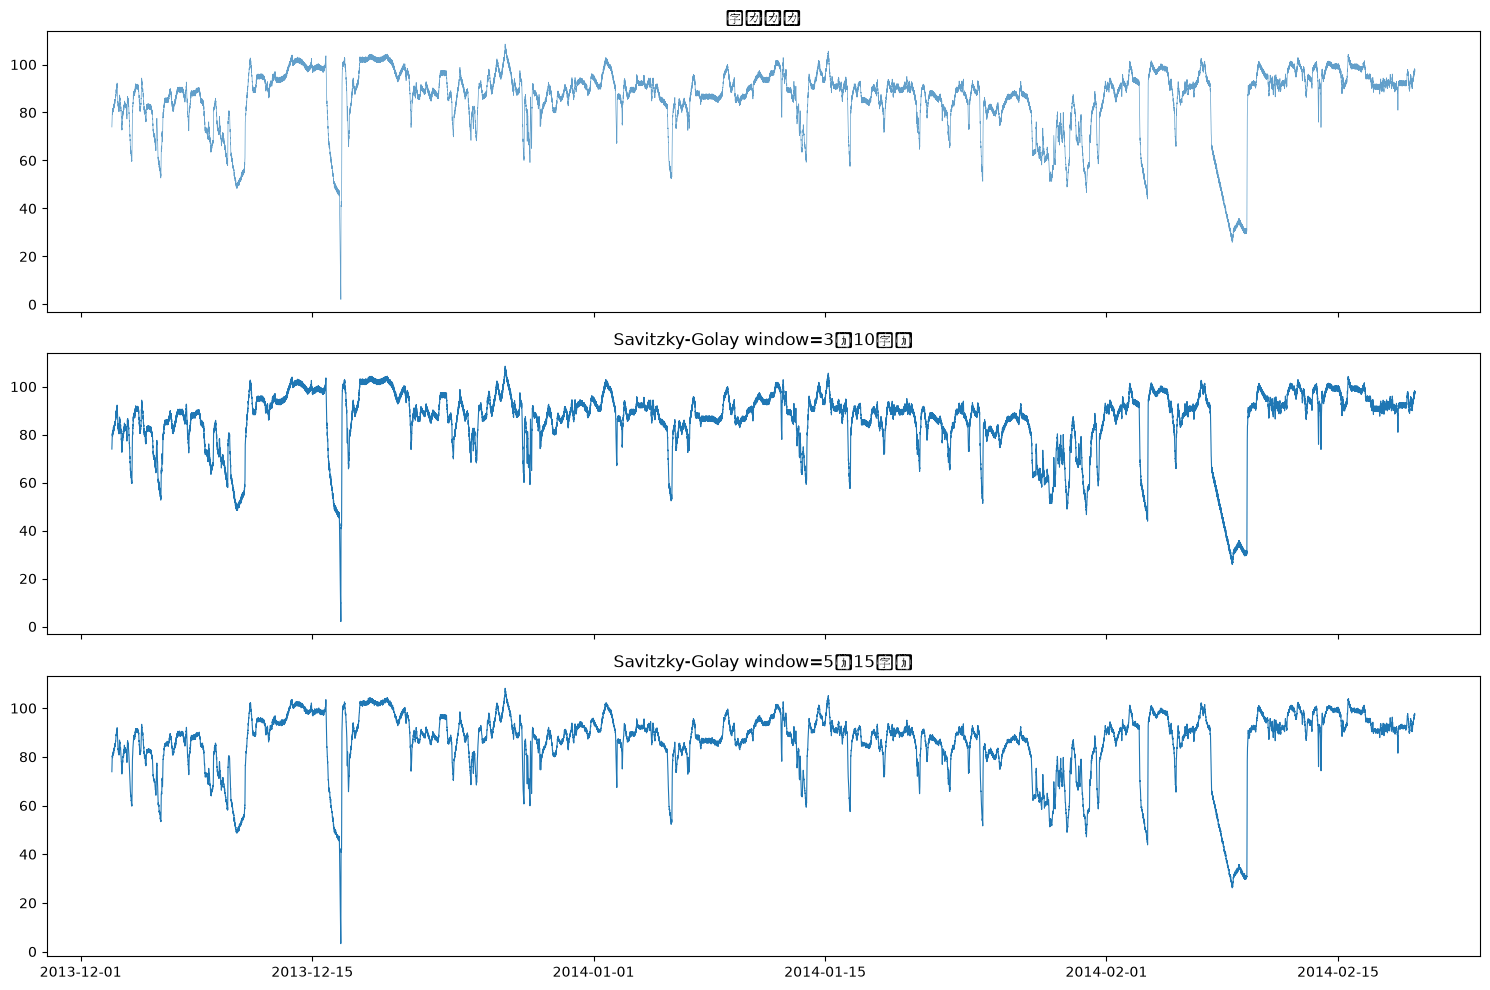

In [4]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 10分窓(3点)と15分窓(5点)で比較
df['sg_3'] = savgol_filter(df['value'], window_length=3, polyorder=2)
df['sg_5'] = savgol_filter(df['value'], window_length=5, polyorder=2)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(df['value'], linewidth=0.5, alpha=0.7)
axes[0].set_title('生データ')

axes[1].plot(df['sg_3'], linewidth=0.8)
axes[1].set_title('Savitzky-Golay window=3（10分）')

axes[2].plot(df['sg_5'], linewidth=0.8)
axes[2].set_title('Savitzky-Golay window=5（15分）')

# https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter  #わかりやすいグラフ

plt.tight_layout()
plt.show()

#サビツキー君でも均せない！！


<Axes: xlabel='timestamp'>

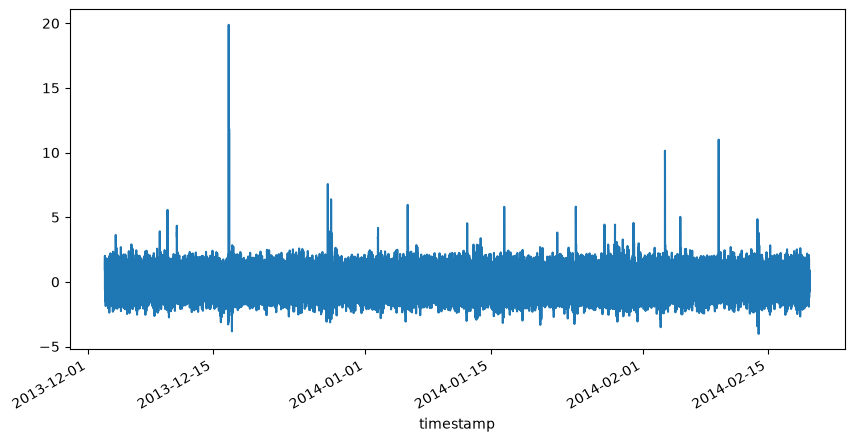

In [5]:
#差分に着目

df['diff'] = df['value'].diff()
df['diff'].plot(figsize=(10,5))
#異常候補が視覚的に確認できた

<Axes: xlabel='timestamp'>

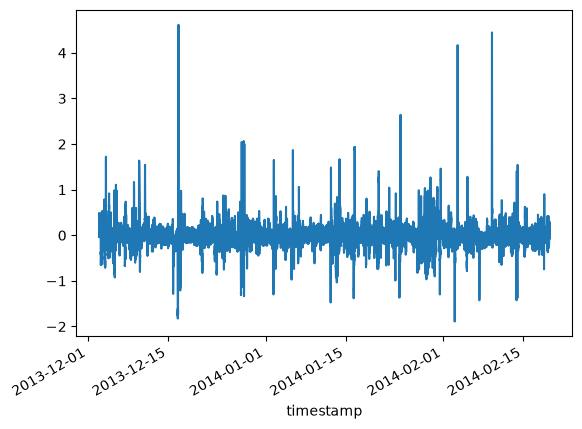

In [6]:
#正常なら上昇下降がペコペコ上下するはず
#下がりきる予兆の下がったままの区間を検知したい

peko=df['diff'].rolling(window=12).mean()
peko.plot()
#温度上昇は急で、下降はゆるやか、平均をとるとプラスに引っ張られなだらかにならない

<Axes: xlabel='timestamp'>

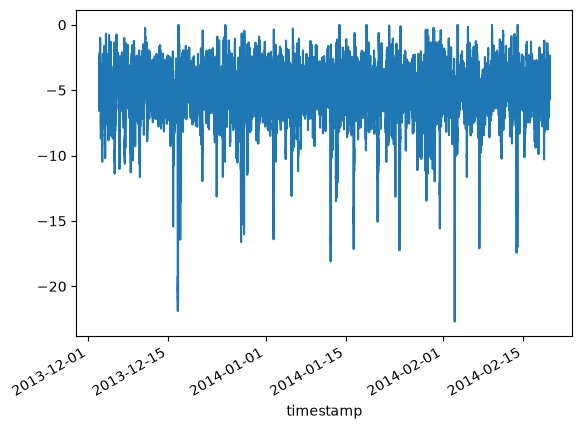

In [7]:
diff_negative = df['diff'].clip(upper=0)  # プラスを全部ゼロに
diff_negative.rolling(window=12).sum().plot()
#異常のマイナス値が大きくてなだらかにならない

3.2304237202142154 -3.228402345509007


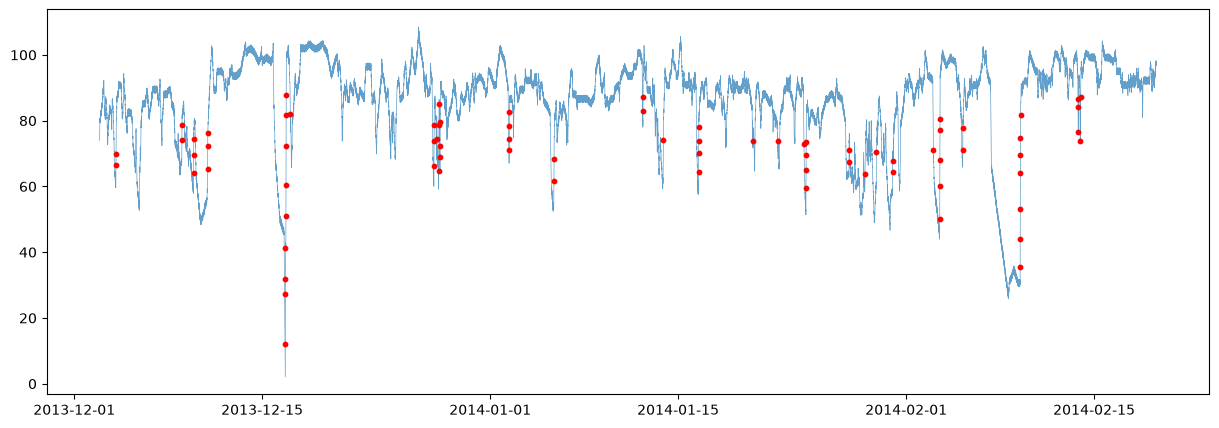

<Axes: >

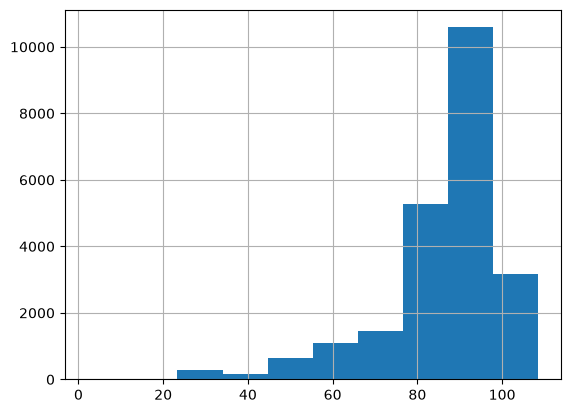

In [8]:
#生データではなく変化量に対して
#値が異常かではなく、変化の速さが異常かわかる

import matplotlib.pyplot as plt
mean=df['diff'].mean()
std=df['diff'].std()
threshold_upper=mean+3*std
threshold_lower=mean-3*std
print(threshold_upper, threshold_lower)

anomalies = df[df['diff'].abs() > 3.23]

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df['value'], linewidth=0.5, alpha=0.7)
ax.scatter(anomalies.index, anomalies['value'], color='red', s=10, zorder=5)
plt.show()
df['value'].hist()


目視の(+-2.5)と上記の3σ(+-3.23)がほぼ一致
つまり3σは「人間が目で見て感じる外れ具合」を数式にしたものに過ぎない

今回の深い谷以外の赤点のように、統計的に外れているけど正常
今回は出なかったが、統計的には普通だが異常ーーーーーーーーー☆今回未確認次の課題
これらは3σだけでは区別が無理

波形によるパターンでの分析
閾値まで下がるかだけでなく、下がり続けるかどうかの判定
この温度なら異常というドメイン知識

これらが必要

[Timestamp('2013-12-16 15:40:00'), Timestamp('2013-12-16 17:25:00')]


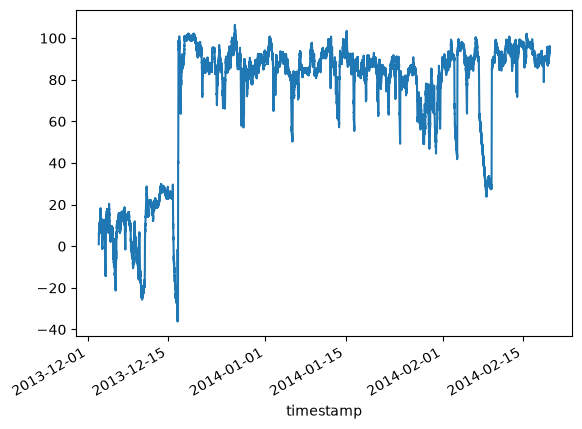

In [ ]:
#cusum  差分の上下動差分をとってプール
#マイナスの閾値（ｈ）越えたらアラート　プール量で調整可

#上下動の差分自体に閾値（ｋ、スラック）を設けて、差分が大きいもののみプールする手法もある
#細かいノイズとそれの蓄積による誤検知に対して有効

c = 0
y = []
anomalies = []
for i, (idx, x) in enumerate(df['diff'].dropna().items()):
    c = c + x
    y.append(c)
    if c < -35:
        anomalies.append(idx)
        c = 0

pd.Series(y, index=df['diff'].dropna().index).plot()
print(anomalies)


